<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/09_pytorch_model_deployment_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09. PyTorch Model Deployment Exercises

Welcome to the 09. PyTorch Model Deployment exercises.

Your objective is to write code to satisify each of the exercises below.

Some starter code has been provided to make sure you have all the resources you need.

> **Note:** There may be more than one solution to each of the exercises.

## Resources

1. These exercises/solutions are based on [section 09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/jOX5ZCkWO-0) (but try the exercises yourself first!).
3. See [all solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

> **Note:** The first section of this notebook is dedicated to getting various helper functions and datasets used for the exercises. The exercises start at the heading "Exercise 1: ...".

### Get various imports and helper functions

The code in the following cells prepares imports and data for the exercises below. They are taken from [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/). 

In [2]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) > 1, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")


torch version: 2.6.0+cu118
torchvision version: 0.21.0+cu118


In [3]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

/home/administrator/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Get data

Want to download the data we've been using in PyTorch Model Deployment: https://www.learnpytorch.io/09_pytorch_model_deployment/#1-getting-data

In [5]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data/pizza_steak_sushi directory exists, skipping download.


PosixPath('data/pizza_steak_sushi')

In [6]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

### Preprocess data

Turn images into tensors using same code as PyTorch Paper Replicating section 2.1 and 2.2: https://www.learnpytorch.io/08_pytorch_paper_replicating/#21-prepare-transforms-for-images

In [7]:
# Create image size (from Table 3 in the ViT paper) 
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])           
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [8]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7f325f32a8c0>,
 ['pizza', 'steak', 'sushi'])

In [9]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(0))

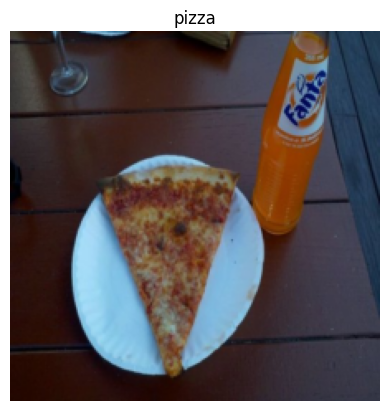

In [10]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

## Exercise 1. Make and time predictions with both feature extractor models on the test dataset using the GPU (`device="cuda"`). 

* Compare the model's prediction times on GPU vs CPU - does this close the gap between them? As in, does making predictions on the GPU make the ViT feature extractor prediction times closer to the EffNetB2 feature extractor prediction times?
* You'll find code to do these steps in [section 5. Making predictions with our trained models and timing them](https://www.learnpytorch.io/09_pytorch_model_deployment/#5-making-predictions-with-our-trained-models-and-timing-them) and [section 6. Comparing model results, prediction times and size](https://www.learnpytorch.io/09_pytorch_model_deployment/#6-comparing-model-results-prediction-times-and-size).

In [11]:
def create_effnetb2_model(num_classes:int=3, seed:int=42):
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    torch.manual_seed(seed=seed)
    model.classifier = nn.Sequential(nn.Dropout(p=0.1), nn.Linear(in_features=1408, out_features=num_classes))
    return model, transforms

In [12]:
effnet_b2, effnet_b2_transforms = create_effnetb2_model()

In [13]:
BATCH_SIZE = 32
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir, test_dir=test_dir, transform=effnet_b2_transforms, batch_size=BATCH_SIZE)

In [14]:
optimizer = torch.optim.Adam(params=effnet_b2.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()
set_seeds()
effnet_b2_results = engine.train(model=effnet_b2, train_dataloader=train_dataloader_effnetb2, test_dataloader=test_dataloader_effnetb2, optimizer=optimizer, loss_fn=loss_fn, epochs=10, device=device)

 10%|█         | 1/10 [00:03<00:27,  3.08s/it]

Epoch: 1 | train_loss: 1.0818 | train_acc: 0.3633 | test_loss: 0.9082 | test_acc: 0.7850


 20%|██        | 2/10 [00:05<00:23,  2.90s/it]

Epoch: 2 | train_loss: 0.8451 | train_acc: 0.8555 | test_loss: 0.8463 | test_acc: 0.7538


 30%|███       | 3/10 [00:08<00:20,  2.88s/it]

...

Epoch: 8 | train_loss: 0.5421 | train_acc: 0.8203 | test_loss: 0.5532 | test_acc: 0.8778


 90%|█████████ | 9/10 [00:25<00:02,  2.77s/it]

Epoch: 9 | train_loss: 0.5001 | train_acc: 0.8359 | test_loss: 0.5209 | test_acc: 0.8977


100%|██████████| 10/10 [00:28<00:00,  2.80s/it]

Epoch: 10 | train_loss: 0.4466 | train_acc: 0.8359 | test_loss: 0.4441 | test_acc: 0.9072


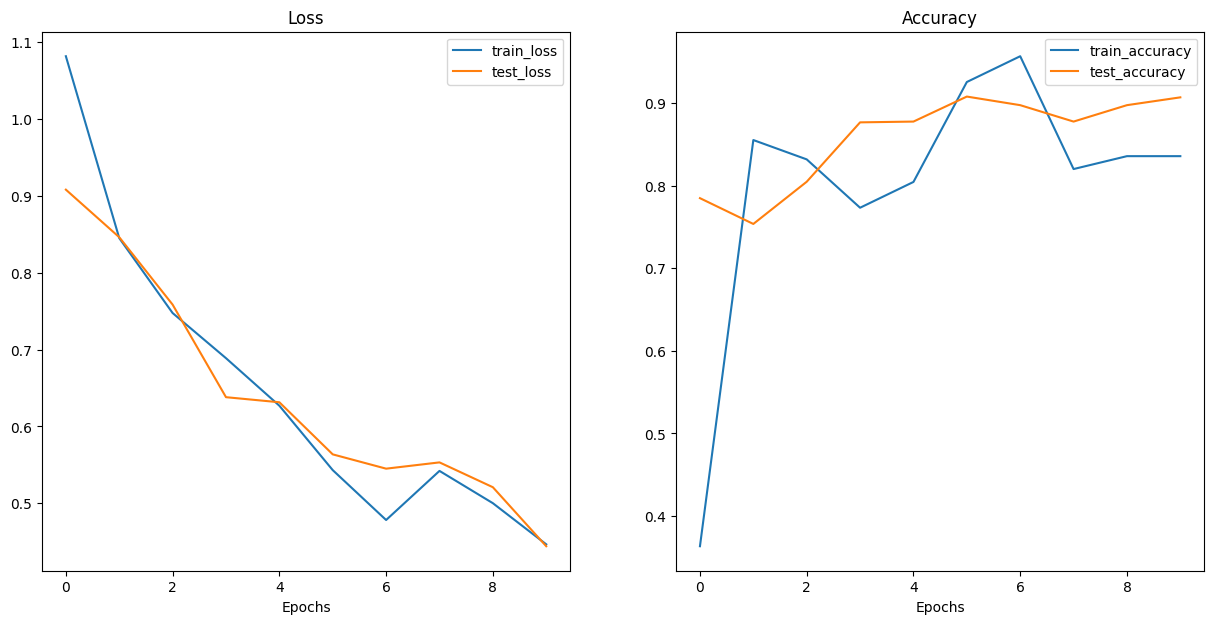

In [15]:
plot_loss_curves(effnet_b2_results)

In [16]:
def create_vit_model(num_classes:int=3, seed:int=42):
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    torch.manual_seed(seed=seed)
    model.heads = nn.Sequential(nn.Linear(in_features=768, out_features=num_classes))
    return model, transforms

In [17]:
vit, vit_transforms = create_vit_model()

In [18]:
BATCH_SIZE = 32
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(train_dir=train_dir, test_dir=test_dir, transform=vit_transforms, batch_size=BATCH_SIZE)

In [19]:
optimizer = torch.optim.Adam(params=vit.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()
set_seeds()
vit_results = engine.train(model=vit, train_dataloader=train_dataloader_vit, test_dataloader=test_dataloader_vit, optimizer=optimizer, loss_fn=loss_fn, epochs=10, device=device)

 10%|█         | 1/10 [00:10<01:31, 10.17s/it]

Epoch: 1 | train_loss: 0.7663 | train_acc: 0.7188 | test_loss: 0.5435 | test_acc: 0.8769


 20%|██        | 2/10 [00:20<01:20, 10.04s/it]

Epoch: 2 | train_loss: 0.3436 | train_acc: 0.9453 | test_loss: 0.3257 | test_acc: 0.8977


 30%|███       | 3/10 [00:30<01:09,  9.98s/it]

...

Epoch: 8 | train_loss: 0.0793 | train_acc: 0.9844 | test_loss: 0.2268 | test_acc: 0.9081


 90%|█████████ | 9/10 [01:30<00:10, 10.04s/it]

Epoch: 9 | train_loss: 0.1084 | train_acc: 0.9883 | test_loss: 0.2064 | test_acc: 0.9384


100%|██████████| 10/10 [01:40<00:00, 10.03s/it]

Epoch: 10 | train_loss: 0.0646 | train_acc: 0.9922 | test_loss: 0.1795 | test_acc: 0.9176


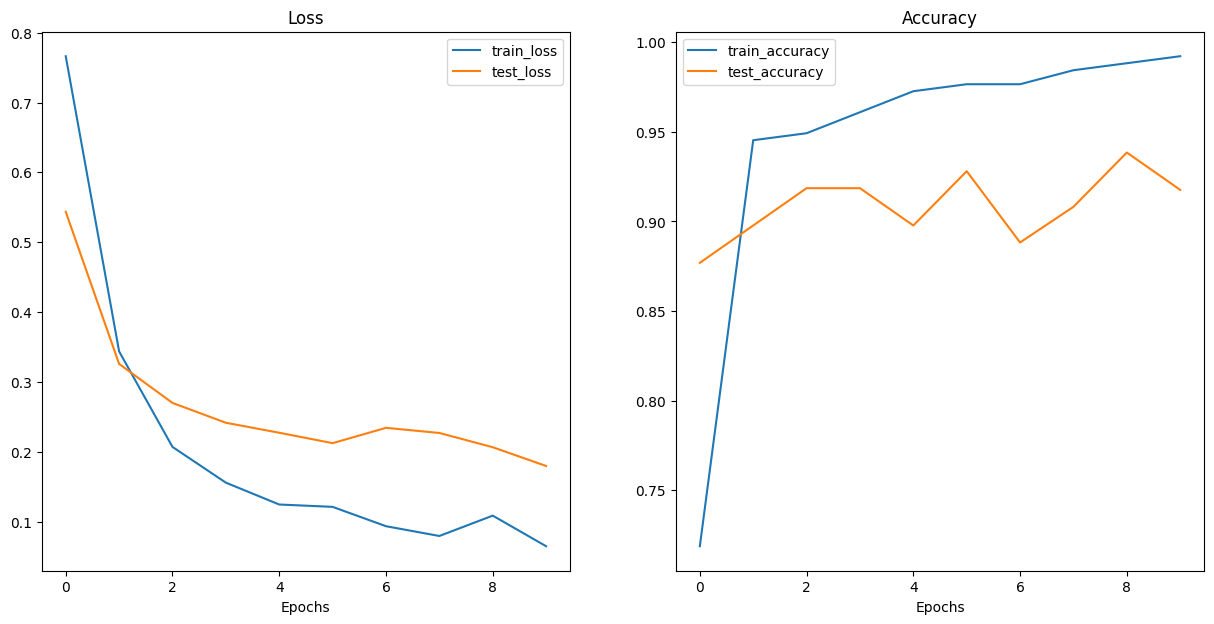

In [20]:
plot_loss_curves(vit_results)

In [21]:
from pathlib import Path

test_image_paths = list(Path(test_dir).glob('*/*.jpg'))

In [22]:
from typing import List
from tqdm.auto import tqdm
from timeit import default_timer as timer
from PIL import Image

def pred_and_store(paths:List[Path], model:nn.Module, transform:torchvision.transforms, class_names:List[str], device:str='cuda' if torch.cuda.is_available() else 'cpu'):
    pred_list = []
    for path in tqdm(test_image_paths):
        pred_dict = {}
        pred_dict['image_path'] = path
        class_name = path.parent.stem
        pred_dict['class_name'] = class_name
        start_time = timer()
        image = Image.open(path)
        transformed_image = transform(image).unsqueeze(dim=0).to(device)
        model = model.to(device)
        model.eval()
        with torch.inference_mode():
            pred_logits = model(transformed_image)
            pred_probs = torch.softmax(pred_logits, dim=1)
            pred_label = torch.argmax(pred_probs, dim=1)
            pred_class = class_names[pred_label]
            pred_dict['pred_probs'] = round(pred_probs.max().cpu().item(), 4)
            pred_dict['pred_class'] = pred_class
            end_time = timer()
            pred_dict['time_for_pred'] = round(end_time - start_time, 4)
            pred_dict['correct'] = (class_name == pred_class)
            pred_list.append(pred_dict)
    return pred_list      

In [23]:
effnetb2_preds_on_cpu = pred_and_store(paths=test_image_paths, model=effnet_b2, transform=effnet_b2_transforms, class_names=class_names, device='cpu')

100%|██████████| 75/75 [00:07<00:00, 10.30it/s]


In [24]:
vit_preds_on_cpu = pred_and_store(paths=test_image_paths, model=vit, transform=vit_transforms, class_names=class_names, device='cpu')

100%|██████████| 75/75 [00:35<00:00,  2.10it/s]


In [25]:
effnetb2_preds_on_gpu = pred_and_store(paths=test_image_paths, model=effnet_b2, transform=effnet_b2_transforms, class_names=class_names, device='cuda')

100%|██████████| 75/75 [00:02<00:00, 37.25it/s]


In [26]:
vit_preds_on_gpu = pred_and_store(paths=test_image_paths, model=vit, transform=vit_transforms, class_names=class_names, device='cuda')

100%|██████████| 75/75 [00:02<00:00, 25.87it/s]


In [27]:
import pandas as pd

def get_mean_pred_time(input):
    df = pd.DataFrame(input)
    return round(df.time_for_pred.mean(), 4)

pred_times = {}
pred_times['effnetb2_cpu'] = get_mean_pred_time(effnetb2_preds_on_cpu)
pred_times['effnetb2_gpu'] = get_mean_pred_time(effnetb2_preds_on_gpu)
pred_times['vit_cpu'] = get_mean_pred_time(vit_preds_on_cpu)
pred_times['vit_gpu'] = get_mean_pred_time(vit_preds_on_gpu)
pred_times_df = pd.DataFrame(pred_times, index=[0])
pred_times_df

,effnetb2_cpu,effnetb2_gpu,vit_cpu,vit_gpu
0,0.0965,0.0266,0.4751,0.0384


## Exercise 2. The ViT feature extractor seems to have more learning capacity (due to more parameters) than EffNetB2, how does it go on the larger 20% split of the entire Food101 dataset?

* Train a ViT feature extractor on the 20% Food101 dataset for 5 epochs, just like we did with EffNetB2 in section [10. Creating FoodVision Big](https://www.learnpytorch.io/09_pytorch_model_deployment/#10-creating-foodvision-big).

In [ ]:
vit_food101_20_percent, vit_food101_20_percent_transforms = create_vit_model(num_classes=101)
summary(model=vit_food101_20_percent, input_size=(1, 3, 224, 224), col_names=['input_size', 'output_size', 'num_params', 'trainable'])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
VisionTransformer                             [1, 3, 224, 224]          [1, 101]                  768                       Partial
├─Conv2d: 1-1                                 [1, 3, 224, 224]          [1, 768, 14, 14]          (590,592)                 False
├─Encoder: 1-2                                [1, 197, 768]             [1, 197, 768]             151,296                   False
│    └─Dropout: 2-1                           [1, 197, 768]             [1, 197, 768]             --                        --
│    └─Sequential: 2-2                        [1, 197, 768]             [1, 197, 768]             --                        False
│    │    └─EncoderBlock: 3-1                 [1, 197, 768]             [1, 197, 768]             (7,087,872)               False
│    │    └─EncoderBlock: 3-2                 [1, 197, 768]             [1, 197, 768]  

In [30]:
vit_food101_20_percent_augmented_transforms = torchvision.transforms.Compose([torchvision.transforms.TrivialAugmentWide(), vit_food101_20_percent_transforms])

In [ ]:
from torchvision import datasets

data_dir = Path('data')
train_data = datasets.Food101(root=data_dir, split='train', transform=vit_food101_20_percent_augmented_transforms, download=True)
test_data = datasets.Food101(root=data_dir, split='test', transform=vit_food101_20_percent_transforms, download=True)

100%|██████████| 5.00G/5.00G [09:23<00:00, 8.86MB/s]  


In [38]:
food101_class_names = train_data.classes

In [39]:
def split_dataset(dataset:torchvision.datasets, split_size:float=0.2, seed:int=42):
    total_length = len(dataset)
    length_1 = int(total_length * split_size)
    length_2 = total_length - length_1
    random_split_1, random_split_2 = torch.utils.data.random_split(dataset=dataset, lengths=[length_1, length_2], generator=torch.manual_seed(seed=seed))
    return random_split_1, random_split_2

In [40]:
train_data_food101_20_percent, _ = split_dataset(dataset=train_data, split_size=0.2)
test_data_food101_20_percent, _ = split_dataset(dataset=test_data, split_size=0.2)

In [41]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 2
train_dataloader_food101 = DataLoader(dataset=train_data_food101_20_percent, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader_food101 = DataLoader(dataset=test_data_food101_20_percent, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [49]:
optimizer = torch.optim.Adam(params=vit_food101_20_percent.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
set_seeds()
vit_food101_20_percent_results = engine.train(model=vit_food101_20_percent, train_dataloader=train_dataloader_food101, test_dataloader=test_dataloader_food101, optimizer=optimizer, loss_fn=loss_fn, epochs=5, device=device)

 20%|██        | 1/5 [10:16<41:04, 616.07s/it]

Epoch: 1 | train_loss: 2.4818 | train_acc: 0.5173 | test_loss: 2.1283 | test_acc: 0.6110


 40%|████      | 2/5 [20:32<30:48, 616.05s/it]

Epoch: 2 | train_loss: 2.3034 | train_acc: 0.5725 | test_loss: 2.0932 | test_acc: 0.6218


 60%|██████    | 3/5 [30:47<20:31, 615.90s/it]

Epoch: 3 | train_loss: 2.2082 | train_acc: 0.6011 | test_loss: 2.0666 | test_acc: 0.6311


 80%|████████  | 4/5 [41:03<10:15, 615.81s/it]

Epoch: 4 | train_loss: 2.1247 | train_acc: 0.6280 | test_loss: 2.0268 | test_acc: 0.6456


100%|██████████| 5/5 [51:19<00:00, 615.82s/it]

Epoch: 5 | train_loss: 2.0954 | train_acc: 0.6379 | test_loss: 2.0232 | test_acc: 0.6440


## Exercise 3. Make predictions across the 20% Food101 test dataset with the ViT feature extractor from exercise 2 and find the "most wrong" predictions
* The predictions will be the ones with the highest prediction probability but with the wrong predicted label.
* Write a sentence or two about why you think the model got these predictions wrong.

In [52]:
test_dataloader_food101_batch_size_1 = DataLoader(dataset=test_data_food101_20_percent, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)
vit_food101_20_percent = vit_food101_20_percent.to(device=device)
vit_food101_20_percent.eval()
vit_food101_pred_list = []
for X, y in tqdm(test_dataloader_food101_batch_size_1):
    X, y = X.to(device=device), y.to(device=device)
    pred_dict = {}
    with torch.inference_mode():
        pred_logits = vit_food101_20_percent(X)
        pred_probs = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_probs, dim=1)
        pred_class = food101_class_names[pred_label]
        pred_dict['pred_prob'] = torch.max(pred_probs).cpu().numpy()
        pred_dict['pred_class'] = pred_class
        pred_dict['true_class'] = food101_class_names[y]
        vit_food101_pred_list.append(pred_dict)

100%|██████████| 5050/5050 [02:51<00:00, 29.37it/s]


In [53]:
vit_food101_pred_list_df = pd.DataFrame(vit_food101_pred_list)
vit_food101_pred_list_df['is_correct'] = (vit_food101_pred_list_df['pred_class'] == vit_food101_pred_list_df['true_class'])
vit_food101_pred_list_df[vit_food101_pred_list_df['is_correct'] == False].sort_values('pred_prob', ascending=False)[:10]

,pred_prob,pred_class,true_class,is_correct
1886,0.97341204,fried_rice,risotto,False
2848,0.9494506,french_onion_soup,bread_pudding,False
3113,0.87704927,creme_brulee,miso_soup,False
2287,0.8689152,fish_and_chips,croque_madame,False
2856,0.8677011,creme_brulee,panna_cotta,False
1889,0.863202,onion_rings,hamburger,False
3398,0.86025167,strawberry_shortcake,ice_cream,False
3465,0.84964776,french_onion_soup,lasagna,False
3031,0.83650863,creme_brulee,tiramisu,False
606,0.8266976,eggs_benedict,croque_madame,False


## Exercise 4. Evaluate the ViT feature extractor across the whole Food101 test dataset rather than just the 20% version, how does it perform?
* Does it beat the original Food101 paper's best result of 56.4% accuracy?

In [54]:
len(test_data)

25250

In [55]:
test_dataloader_food101_all_batch_size_1 = DataLoader(dataset=test_data, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

In [56]:
vit_food101_20_percent = vit_food101_20_percent.to(device=device)
vit_food101_20_percent.eval()
vit_food101_all_pred_list = []
for X, y in tqdm(test_dataloader_food101_all_batch_size_1):
    X, y = X.to(device=device), y.to(device=device)
    with torch.inference_mode():
        pred_logits = vit_food101_20_percent(X)
        pred_probs = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_probs, dim=1)
        pred_class = food101_class_names[pred_label]
        pred_dict = {}
        pred_dict['pred_prob'] = torch.max(pred_probs).cpu().numpy()
        pred_dict['pred_class'] = pred_class
        pred_dict['true_class'] = food101_class_names[y]
        vit_food101_all_pred_list.append(pred_dict)

100%|██████████| 25250/25250 [14:27<00:00, 29.11it/s]


In [63]:
vit_food101_all_pred_list_df = pd.DataFrame(vit_food101_all_pred_list)
vit_food101_all_pred_list_df['is_correct'] = (vit_food101_all_pred_list_df['pred_class'] == vit_food101_all_pred_list_df['true_class'])
vit_food101_all_pred_list_df.is_correct.value_counts()
print(f'Accuracy on whole test dataset containing {len(test_data)} samples is {len(vit_food101_all_pred_list_df[vit_food101_all_pred_list_df["is_correct"] == False]) / len(vit_food101_all_pred_list_df):.4f}.')

Accuracy on whole test dataset containing 25250 samples is 0.3513.


## Exercise 5. Head to [Paperswithcode.com](https://paperswithcode.com/) and find the current best performing model on the Food101 dataset.
* What model architecture does it use?

In [45]:
# TODO: your answer to the above

## Exercise 6. Write down 1-3 potential failure points of our deployed FoodVision models and what some potential solutions might be.
* For example, what happens if someone was to upload a photo that wasn't of food to our FoodVision Mini model?

## Exercise 7. Pick any dataset from [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) and train a feature extractor model on it using a model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) (you could use one of the model's we've already created, e.g. EffNetB2 or ViT) for 5 epochs and then deploy your model as a Gradio app to Hugging Face Spaces. 
* You may want to pick smaller dataset/make a smaller split of it so training doesn't take too long.
* I'd love to see your deployed models! So be sure to share them in Discord or on the [course GitHub Discussions page](https://github.com/mrdbourke/pytorch-deep-learning/discussions).

In [106]:
!rm -rf demos
!mkdir demos
!cd demos && mkdir foodvision_big
!cd demos/foodvision_big && mkdir examples

In [107]:
!wget https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg
!mv 04-pizza-dad.jpeg demos/foodvision_big/examples/04-pizza-dad.jpg

--2025-04-19 07:14:21--  https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: ‘04-pizza-dad.jpeg’

04-pizza-dad.jpeg   100%[===================>]   2.74M  10.3MB/s    in 0.3s    

2025-04-19 07:14:21 (10.3 MB/s) - ‘04-pizza-dad.jpeg’ saved [2874848/2874848]



In [123]:
from going_modular.going_modular import utils

utils.save_model(model=vit_food101_20_percent, target_dir='demos/foodvision_big/models', model_name='vit_food101_20_percent.pth')

[INFO] Saving model to: demos/foodvision_big/models/vit_food101_20_percent.pth


In [109]:
with open('demos/foodvision_big/foodvision_big_class_names.txt', 'w') as f:
    f.write('\n'.join(food101_class_names))

In [111]:
%%writefile demos/foodvision_big/model.py

import torch
import torchvision
from torch import nn

def create_vit_food101_20_percent_model(num_classes:int=101, seed:int=42):
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    torch.manual_seed(seed=seed)
    model.heads = nn.Sequential(nn.Linear(in_features=768, out_features=num_classes))
    return model, transforms

Overwriting demos/foodvision_big/model.py


In [137]:
%%writefile demos/foodvision_big/app.py

from timeit import default_timer as timer
import os
import gradio
from model import create_vit_food101_20_percent_model
import torch

with open('foodvision_big_class_names.txt', 'r') as f:
    class_names = [food_name.strip() for food_name in f.readlines()]
model, transforms = create_vit_food101_20_percent_model(num_classes=101, seed=42)
model.load_state_dict(torch.load(f='models/vit_food101_20_percent.pth'))

def predict(image):
    start_time = timer()
    transformed_image = transforms(image).unsqueeze(0)
    model.eval()
    with torch.inference_mode():
        pred_probs = torch.softmax(model(transformed_image), dim=1)
        pred_probs_and_labels = {class_names[i]: pred_probs[0][i] for i in range(len(class_names))}
        pred_time = round(timer() - start_time, 4)
        return pred_probs_and_labels, pred_time

title = 'Food Vision Big'
description = 'Using the Food Vision Big model to predict type of food from 101 pre-defined classes.'
article = 'Created for deployment.'
examples = [['examples/' + example] for example in os.listdir('examples')]
demo = gradio.Interface(fn=predict, inputs=gradio.Image(type='pil'), outputs=[gradio.Label(num_top_classes=5, label='Predictions'), gradio.Number(label='Prediction time (s)')], examples=examples, title=title, description=description, article=article)
demo.launch(server_name='0.0.0.0', server_port=7861, share=False)

Overwriting demos/foodvision_big/app.py


In [112]:
%%writefile demos/foodvision_big/requirements.txt
torch==1.12.0
torchvision==0.13.0
gradio==3.1.4

Writing demos/foodvision_big/requirements.txt
